# Условное восстановление пульсовых изменений удельного сопротивления

## Цель расчёта

Ноутбук проверяет, можно ли в рамках двуслойной плоской полубесконечной модели
разделить ЭКГ-синхронизированный сигнал боковых сборок на две модельные
составляющие: изменение удельного сопротивления мягких тканей
$\Delta\rho_1$ и изменение удельного сопротивления лёгкого $\Delta\rho_2$.
Расчёт относится только к эксперименту 2.

Входной пульсовой сигнал берётся из `33.03` без повторного выделения
кардиоциклов. Статические рабочие точки берутся из сценарного профиля `33.06`.
Толщина мягких тканей $h$ не выбирается по минимуму этого профиля: минимум на
границе $1$ мм уже признан признаком неустойчивости статической обратной задачи.
Вместо одного ответа выполняется расчёт по всей имеющейся сетке $h$.

Результат имеет статус исследовательской гипотезы. Он показывает математическую
согласованность измеренного размерного ряда с выбранным оператором, но не
является измерением физических $\Delta\rho_1$ и $\Delta\rho_2$.


## Входы и границы ответственности

Используются два внешних обезличенных артефакта:

1. `33.03_pulse_ensembles.provisional.json` — медианные формы `RHEO2` для
   каждого добровольца, размера и состояния дыхания на нормированной фазе
   интервала R–R;
2. `33.06_side_arrays_exploratory.json` — статические решения
   $(\rho_1,\rho_2)$ для вычислительной сетки $h=1\ldots80$ мм при условном
   прочтении `BASE2` с единичными коэффициентами.

Ноутбук не определяет дыхательные интервалы, R-зубцы, пригодность циклов,
анатомическую толщину $h$ или калибровку каналов. Эти решения принадлежат
предыдущим документам. Результаты `33.03` и `33.06` имеют предварительный
статус, поэтому их объединение допустимо только для разработки методики.

Размеры сборок регистрировались последовательно. Совместная инверсия
предполагает, что одинаковая фаза R–R в разных записях соответствует одной и
той же скрытой форме $\Delta\rho_1(\varphi)$ и $\Delta\rho_2(\varphi)$. Это
сильное допущение: различия записей могут быть связаны не только с размером,
но и со временем, контактом электродов, состоянием добровольца и
межканальным влиянием.


## Линеаризованная модель

В окрестности выбранной статической рабочей точки для каждой сборки размера
$L$ используется приближение

$$
\Delta Z_L(\varphi)=
\frac{\partial Z_L}{\partial\rho_1}\Delta\rho_1(\varphi)+
\frac{\partial Z_L}{\partial\rho_2}\Delta\rho_2(\varphi)+
\varepsilon_L(\varphi),
$$

где $\varphi$ — безразмерная фаза интервала R–R; $Z_L$ — передаточный
импеданс двуслойной модели; $\rho_1$ и $\rho_2$ — статические удельные
сопротивления мягких тканей и лёгкого; $\Delta\rho_1$ и $\Delta\rho_2$ —
искомые модельные изменения относительно условного нулевого уровня ансамбля;
$\varepsilon_L$ — остаток, не представленный двумя столбцами оператора.
Остаток не называется случайным шумом: в него могут входить несоответствие
физической модели, межзаписная изменчивость, приборные эффекты и ошибки
предыдущей обработки.

Для всех размеров у одного добровольца и одного состояния дыхания уравнения
объединяются в матричную систему $\mathbf y(\varphi)=\mathbf A\mathbf
x(\varphi)+\boldsymbol\varepsilon(\varphi)$. Условная оценка имеет вид

$$
\widehat{\mathbf x}(\varphi)=\mathbf A^{+}\mathbf y(\varphi),
$$

где $\mathbf y$ — вектор ансамблевых значений для разных размеров;
$\mathbf A$ — матрица производных по $\rho_1$ и $\rho_2$; $\mathbf A^{+}$ —
псевдообратная матрица Мура—Пенроуза; $\widehat{\mathbf x}=(\widehat{
\Delta\rho_1},\widehat{\Delta\rho_2})^\mathsf T$ — условные модельные
коэффициенты.

Номинальный перевод столбца `RHEO_2_mΩ` в омы задаётся множителем $10^{-3}$.
Неизвестные физический знак $s\in\{-1,+1\}$ и коэффициент пульсовой
калибровки $g_p>0$ в расчёт не подставляются. Показанные кривые соответствуют
$s=+1$ и $g_p=1$. Для другого сценария обе кривые $\Delta\rho$ умножаются на
$s g_p$; число обусловленности, относительная невязка и выбранная пара
размеров не меняются. Поэтому амплитуды ниже выражены **на единицу
неизвестного коэффициента $g_p$**.


## Проверки устойчивости

Для каждой рабочей точки вычисляются следующие диагностические показатели.

- Ранг матрицы показывает, существуют ли в ней два линейно независимых
  направления чувствительности. Полный ранг необходим, но не гарантирует
  устойчивость решения.
- Число обусловленности и модуль косинуса между столбцами характеризуют
  алгебраическую близость вкладов мягких тканей и лёгкого.
- Относительная норма остатка показывает, какая часть измеренной размерно-
  фазовой матрицы не лежит в двумерном модельном подпространстве.
- Поочерёдное исключение одного размера проверяет зависимость результата от
  отдельной последовательной записи.
- Сравнение с вариантом `33.03` без циклов с кандидатной меткой ЭКГ оценивает
  влияние ранее отмеченных спорных циклов.
- Перебор пар размеров определяет наиболее устойчивую пару только в смысле
  числа обусловленности выбранного аналитического оператора. Два размера дают
  формально точное решение двух уравнений, но не оставляют независимых данных
  для проверки остатка.

Вероятностная модель совокупной ошибки не задана. Поэтому доверительные
интервалы, статистическая значимость и искусственное добавление случайного
шума здесь не используются.


In [1]:
from __future__ import annotations

from datetime import datetime, timezone
from itertools import combinations
import json
import os
from pathlib import Path

from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from two_layer_model import evaluate, geometry_from_size

CONFIG_ENV = "KALMYKOV_EXP02_CONFIG"
ALGORITHM_VERSION = "series33-delta-rho-scenario-v2"
EXPLORATORY_STATUS = "exploratory_hypothesis_not_validated"
NOMINAL_MOHM_TO_OHM = 1.0e-3
SELECTED_H_MM = (1, 5, 10, 15, 20, 40, 60, 80)
CORE_H_MAX_MM = 20
WAVEFORM_H_MM = (1, 5, 10, 15, 20)
MODE_LABELS = {
    "задержка_вдох": "после вдоха",
    "задержка_выдох": "после выдоха",
}
MODE_TO_STATE = {
    "задержка_вдох": "inhale",
    "задержка_выдох": "exhale",
}

plt.rcParams.update({
    "axes.grid": True,
    "grid.alpha": 0.22,
    "figure.dpi": 110,
})
pd.set_option("display.max_rows", 100)


In [2]:
def json_ready(value):
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, dict):
        return {key: json_ready(child) for key, child in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_ready(child) for child in value]
    return value


def matrix_diagnostics(matrix):
    matrix = np.asarray(matrix, dtype=float)
    singular = np.linalg.svd(matrix, compute_uv=False)
    rank = int(np.linalg.matrix_rank(matrix))
    condition = (
        float(singular[0] / singular[-1])
        if singular[-1] > 0 else float("inf")
    )
    first = matrix[:, 0]
    second = matrix[:, 1]
    denominator = np.linalg.norm(first) * np.linalg.norm(second)
    column_cosine = (
        float(abs(np.dot(first, second) / denominator))
        if denominator > 0 else float("nan")
    )
    return {
        "rank": rank,
        "singular_values": singular,
        "condition": condition,
        "absolute_column_cosine": column_cosine,
        "pseudoinverse_norm_ohm_m_per_ohm": (
            float(1.0 / singular[-1]) if singular[-1] > 0 else float("inf")
        ),
    }


def two_layer_operator(sizes_mm, static_row, state):
    rho1 = float(static_row["rho1_ohm_m"])
    rho2 = float(static_row[f"rho2_{state}_ohm_m"])
    h_m = float(static_row["h_m"])
    rows = []
    for size_mm in np.asarray(sizes_mm, dtype=float):
        a, b = geometry_from_size(float(size_mm) / 1000.0)
        result = evaluate(rho1, rho2, h_m, a, b)
        rows.append([result.d_rho1, result.d_rho2])
    return np.asarray(rows, dtype=float)


def invert_waveforms(operator, waveforms_ohm):
    operator = np.asarray(operator, dtype=float)
    waveforms = np.asarray(waveforms_ohm, dtype=float)
    if waveforms.ndim != 2 or waveforms.shape[0] != operator.shape[0]:
        raise ValueError("Ожидается матрица размер × фаза")
    diagnostics = matrix_diagnostics(operator)
    if diagnostics["rank"] < 2:
        raise RuntimeError("Оператор не разделяет два модельных вклада")
    solution, _, _, _ = np.linalg.lstsq(operator, waveforms, rcond=None)
    predicted = operator @ solution
    residual = waveforms - predicted
    input_norm = float(np.linalg.norm(waveforms))
    residual_norm = float(np.linalg.norm(residual))
    relative_residual = residual_norm / input_norm if input_norm > 0 else np.nan
    return {
        **diagnostics,
        "solution_ohm_m_per_unit_gain": solution,
        "predicted_ohm_per_unit_gain": predicted,
        "residual_ohm_per_unit_gain": residual,
        "relative_residual_norm": relative_residual,
        "represented_squared_norm_fraction": (
            1.0 - relative_residual ** 2 if np.isfinite(relative_residual) else np.nan
        ),
        "component_ptp_ohm_m_per_unit_gain": np.ptp(solution, axis=1),
        "residual_rms_by_size_ohm_per_unit_gain": np.sqrt(
            np.mean(residual ** 2, axis=1)
        ),
    }


def relative_curve_change(reference, alternative):
    reference = np.asarray(reference, dtype=float)
    alternative = np.asarray(alternative, dtype=float)
    denominator = float(np.linalg.norm(reference))
    return (
        float(np.linalg.norm(alternative - reference) / denominator)
        if denominator > 0 else float("nan")
    )


def pair_diagnostics(operator, sizes_mm):
    rows = []
    for first, second in combinations(range(len(sizes_mm)), 2):
        pair = operator[[first, second], :]
        diagnostics = matrix_diagnostics(pair)
        if diagnostics["rank"] < 2:
            continue
        rows.append({
            "sizes_mm": [int(sizes_mm[first]), int(sizes_mm[second])],
            "condition": diagnostics["condition"],
            "pseudoinverse_norm_ohm_m_per_ohm": diagnostics[
                "pseudoinverse_norm_ohm_m_per_ohm"
            ],
            "absolute_determinant": float(abs(np.linalg.det(pair))),
        })
    if not rows:
        raise RuntimeError("Ни одна пара размеров не имеет полного ранга")
    rows.sort(key=lambda item: (item["condition"], item["pseudoinverse_norm_ohm_m_per_ohm"]))
    return rows


def analyze_scenario(sizes_mm, primary_ohm, no_flag_ohm, static_row, state):
    operator = two_layer_operator(sizes_mm, static_row, state)
    primary = invert_waveforms(operator, primary_ohm)
    no_flag = invert_waveforms(operator, no_flag_ohm)
    primary_solution = primary["solution_ohm_m_per_unit_gain"]
    no_flag_solution = no_flag["solution_ohm_m_per_unit_gain"]

    leave_one_out = []
    for removed_index, removed_size in enumerate(sizes_mm):
        keep = np.ones(len(sizes_mm), dtype=bool)
        keep[removed_index] = False
        reduced = invert_waveforms(operator[keep], primary_ohm[keep])
        reduced_solution = reduced["solution_ohm_m_per_unit_gain"]
        leave_one_out.append({
            "removed_size_mm": int(removed_size),
            "component_curve_change_fraction": [
                relative_curve_change(primary_solution[index], reduced_solution[index])
                for index in range(2)
            ],
            "component_ptp_ohm_m_per_unit_gain": np.ptp(
                reduced_solution, axis=1
            ),
            "relative_residual_norm": reduced["relative_residual_norm"],
        })

    all_pairs = pair_diagnostics(operator, sizes_mm)
    return {
        "h_m": float(static_row["h_m"]),
        "static_rho1_ohm_m": float(static_row["rho1_ohm_m"]),
        "static_rho2_ohm_m": float(static_row[f"rho2_{state}_ohm_m"]),
        "static_parameter_bound_hit": bool(static_row["parameter_bound_hit"]),
        "operator_ohm_per_ohm_m": operator,
        "operator_rank": primary["rank"],
        "operator_singular_values": primary["singular_values"],
        "operator_condition": primary["condition"],
        "operator_absolute_column_cosine": primary["absolute_column_cosine"],
        "operator_pseudoinverse_norm_ohm_m_per_ohm": primary[
            "pseudoinverse_norm_ohm_m_per_ohm"
        ],
        "delta_rho1_ohm_m_per_unit_gain": primary_solution[0],
        "delta_rho2_ohm_m_per_unit_gain": primary_solution[1],
        "component_ptp_ohm_m_per_unit_gain": primary[
            "component_ptp_ohm_m_per_unit_gain"
        ],
        "relative_residual_norm": primary["relative_residual_norm"],
        "represented_squared_norm_fraction": primary[
            "represented_squared_norm_fraction"
        ],
        "residual_rms_by_size_ohm_per_unit_gain": primary[
            "residual_rms_by_size_ohm_per_unit_gain"
        ],
        "candidate_flag_component_curve_change_fraction": [
            relative_curve_change(primary_solution[index], no_flag_solution[index])
            for index in range(2)
        ],
        "candidate_flag_component_ptp_ohm_m_per_unit_gain": np.ptp(
            no_flag_solution, axis=1
        ),
        "leave_one_size_out": leave_one_out,
        "best_conditioned_pair": all_pairs[0],
        "all_pair_diagnostics": all_pairs,
    }


In [3]:
# Синтетическая проверка подтверждает реализацию линейной алгебры,
# но не проверяет экспериментальные данные или двуслойную физическую модель.
sizes_test = np.asarray([50, 70, 90, 110, 140])
static_test = {
    "h_m": 0.020,
    "rho1_ohm_m": 5.0,
    "rho2_inhale_ohm_m": 18.0,
    "rho2_exhale_ohm_m": 14.0,
    "parameter_bound_hit": False,
}
operator_test = two_layer_operator(sizes_test, static_test, "inhale")
phase_test = np.linspace(0.0, 1.0, 200, endpoint=False)
truth_test = np.vstack([
    2.0e-3 * np.sin(2.0 * np.pi * phase_test),
    -5.0e-3 * np.cos(2.0 * np.pi * phase_test),
])
waveforms_test = operator_test @ truth_test
recovered_test = invert_waveforms(operator_test, waveforms_test)
assert recovered_test["rank"] == 2
assert recovered_test["relative_residual_norm"] < 1.0e-12
assert np.max(np.abs(recovered_test["solution_ohm_m_per_unit_gain"] - truth_test)) < 1.0e-12
assert len(pair_diagnostics(operator_test, sizes_test)) == 10
print("Синтетическая проверка линейной инверсии выполнена")


Синтетическая проверка линейной инверсии выполнена


In [4]:
config_value = os.environ.get(CONFIG_ENV)
if not config_value:
    raise RuntimeError(f"Перед запуском задайте {CONFIG_ENV}")

config_path = Path(config_value).expanduser().resolve()
config = json.loads(config_path.read_text(encoding="utf-8"))
derived_root = Path(config["derived_root"]).expanduser().resolve()
exploratory_dir = derived_root / "exp02" / "exploratory"
pulse_path = exploratory_dir / "33.03_pulse_ensembles.provisional.json"
static_path = exploratory_dir / "33.06_side_arrays_exploratory.json"

pulse_artifact = json.loads(pulse_path.read_text(encoding="utf-8"))
static_artifact = json.loads(static_path.read_text(encoding="utf-8"))
if pulse_artifact.get("schema_version") != 2:
    raise RuntimeError("Неизвестная схема артефакта 33.03")
if pulse_artifact.get("status") != EXPLORATORY_STATUS:
    raise RuntimeError("33.03 не имеет исследовательского статуса")
if static_artifact.get("status") != EXPLORATORY_STATUS:
    raise RuntimeError("33.06 не имеет исследовательского статуса")
if static_artifact.get("strict_pipeline_authorized") is not False:
    raise RuntimeError("Сценарный артефакт 33.06 ошибочно помечен как строгий")

subject_labels = {
    item["subject_id"]: item.get("report_label", item["subject_id"])
    for item in config["subjects"]
}
ensemble_index = {}
for item in pulse_artifact["ensembles"]:
    key = (item["subject_id"], int(item["size_mm"]), item["mode"])
    if key in ensemble_index:
        raise RuntimeError(f"Повторный ансамбль: {key}")
    if item.get("signal_unit") != "mOhm_native_file_scale":
        raise RuntimeError("33.03 содержит неожиданную шкалу сигнала")
    ensemble_index[key] = item

if set(static_artifact["subjects"]) != set(subject_labels):
    raise RuntimeError("Набор добровольцев 33.06 не совпадает с конфигурацией")

subject_results = {}
summary_rows = []
for subject_id, static_subject in sorted(static_artifact["subjects"].items()):
    sizes_mm = np.asarray(static_subject["sizes_mm"], dtype=int)
    profile = static_subject["static_h_profile"]["profile"]
    h_mm_values = np.asarray([1000.0 * float(row["h_m"]) for row in profile])
    if not np.array_equal(np.rint(h_mm_values).astype(int), np.arange(1, 81)):
        raise RuntimeError("33.06 не содержит ожидаемую сетку h=1…80 мм")

    modes_result = {}
    for mode, mode_label in MODE_LABELS.items():
        primary = []
        no_flag = []
        phase_grid = None
        for size_mm in sizes_mm:
            key = (subject_id, int(size_mm), mode)
            if key not in ensemble_index:
                raise RuntimeError(f"Нет ансамбля 33.03 для {key}")
            ensemble = ensemble_index[key]
            current_phase = np.asarray(ensemble["phase_rr"], dtype=float)
            if phase_grid is None:
                phase_grid = current_phase
            elif not np.array_equal(phase_grid, current_phase):
                raise RuntimeError("Фазовые сетки 33.03 не совпадают")
            primary.append(
                np.asarray(ensemble["primary"]["median_mohm"], dtype=float)
                * NOMINAL_MOHM_TO_OHM
            )
            no_flag.append(
                np.asarray(
                    ensemble["sensitivity_without_candidate_ecg_flags"]["median_mohm"],
                    dtype=float,
                ) * NOMINAL_MOHM_TO_OHM
            )
        primary = np.asarray(primary)
        no_flag = np.asarray(no_flag)
        scenarios = []
        for static_row in profile:
            scenario = analyze_scenario(
                sizes_mm,
                primary,
                no_flag,
                static_row,
                MODE_TO_STATE[mode],
            )
            scenarios.append(scenario)
            h_mm = int(round(1000.0 * scenario["h_m"]))
            if h_mm in SELECTED_H_MM:
                loo_max = np.nanmax([
                    max(item["component_curve_change_fraction"])
                    for item in scenario["leave_one_size_out"]
                ])
                flag_max = np.nanmax(
                    scenario["candidate_flag_component_curve_change_fraction"]
                )
                summary_rows.append({
                    "Доброволец": subject_labels[subject_id],
                    "Состояние": mode_label,
                    "h, мм": h_mm,
                    "Ранг": scenario["operator_rank"],
                    "Число обусловленности": scenario["operator_condition"],
                    "|cos столбцов|": scenario[
                        "operator_absolute_column_cosine"
                    ],
                    "Относительный остаток, %": (
                        100.0 * scenario["relative_residual_norm"]
                    ),
                    "Размах Δρ1/gp, мОм·м": (
                        1000.0
                        * scenario["component_ptp_ohm_m_per_unit_gain"][0]
                    ),
                    "Размах Δρ2/gp, мОм·м": (
                        1000.0
                        * scenario["component_ptp_ohm_m_per_unit_gain"][1]
                    ),
                    "Макс. изменение при исключении размера, %": 100.0 * loo_max,
                    "Макс. изменение без спорных циклов, %": 100.0 * flag_max,
                    "Лучшая пара": "–".join(
                        map(str, scenario["best_conditioned_pair"]["sizes_mm"])
                    ),
                    "Параметр статической модели на границе": scenario[
                        "static_parameter_bound_hit"
                    ],
                })
        modes_result[mode] = {
            "mode_label": mode_label,
            "phase_rr": phase_grid,
            "sizes_mm": sizes_mm,
            "scenarios": scenarios,
        }
    subject_results[subject_id] = {
        "report_label": subject_labels[subject_id],
        "modes": modes_result,
    }

result_artifact = {
    "schema_version": 2,
    "analysis": "33.04_conditional_dynamic_two_layer_inverse",
    "algorithm_version": ALGORITHM_VERSION,
    "status": EXPLORATORY_STATUS,
    "created_at": datetime.now(timezone.utc).isoformat(),
    "experiment": 2,
    "strict_pipeline_authorized": False,
    "upstream": {
        "pulse_ensembles": pulse_path.name,
        "static_scenarios": static_path.name,
    },
    "calibration_scenario": {
        "nominal_mohm_to_ohm": NOMINAL_MOHM_TO_OHM,
        "pulse_gain": "unknown_results_are_per_unit_gain",
        "physical_sign": "unknown_opposite_sign_negates_both_components",
        "static_working_points": "unvalidated_33.06_BASE2_gain1_offset0_sign_plus",
    },
    "assumptions": [
        "two_layer_flat_halfspace_is_applicable",
        "linearization_is_adequate_for_the_pulse_excursion",
        "sequential_size_recordings_share_one_latent_phase_normalized_response",
        "h_is_fixed_within_each_scenario_and_equal_for_both_breathing_states",
        "rho1_static_working_point_is_shared_between_breathing_states",
        "size_specific_channel_gain_is_absent",
        "unweighted_least_squares_is_used_only_as_a_diagnostic_without_error_covariance",
    ],
    "limitations": [
        "absolute_delta_rho_is_not_identified_without_pulse_calibration",
        "physical_sign_is_unknown",
        "static_working_points_are_scenario_values_not_validated_tissue_properties",
        "rr_phase_alignment_is_not_absolute_time_alignment",
        "no_probabilistic_error_model_or_confidence_intervals",
        "two_size_solution_cannot_test_model_residual",
        "no_ct_fem_validation_of_sensitivity_operator",
    ],
    "subjects": subject_results,
}

out_path = exploratory_dir / "33.04_delta_rho_scenarios.provisional.json"
temporary_path = out_path.with_suffix(out_path.suffix + ".tmp")
temporary_path.write_text(
    json.dumps(json_ready(result_artifact), ensure_ascii=False, indent=2) + "\n",
    encoding="utf-8",
)
temporary_path.replace(out_path)

summary_df = pd.DataFrame(summary_rows).sort_values(
    ["Доброволец", "Состояние", "h, мм"]
).reset_index(drop=True)
print(
    f"Проанализировано {len(subject_results)} добровольца, "
    f"{len(summary_rows) // len(SELECTED_H_MM)} сочетания добровольца и "
    f"состояния дыхания, {len(profile)} сценариев h для каждого сочетания."
)
print("Внешний исследовательский результат:", out_path.name)


Проанализировано 2 добровольца, 4 сочетания добровольца и состояния дыхания, 80 сценариев h для каждого сочетания.
Внешний исследовательский результат: 33.04_delta_rho_scenarios.provisional.json


## Численные результаты

В таблице приведены выбранные точки полной сетки $h$. Диапазон 1–20 мм считается основным расчётным диапазоном только потому, что ранее для него был принят детальный шаг; анатомическим априорным диапазоном он не является. Размах $\Delta\rho/g_p$
показывает амплитудный диапазон условной модельной компоненты при единичном
коэффициенте пульсовой калибровки. «Относительный остаток» равен отношению
евклидовой нормы остаточной матрицы к норме входной размерно-фазовой матрицы.
Показатели исключения размера и спорных циклов сравнивают всю форму
восстановленной компоненты, а не только её максимум. Отметка о границе
указывает, что хотя бы один параметр статической подгонки достиг границы заданного
численного диапазона; такие сценарии показываются как диагностика срыва
модели и не интерпретируются количественно.

Пара размеров в последнем столбце минимизирует число обусловленности среди
всех доступных пар при данном $h$. Такая пара является алгебраическим
кандидатом и не заменяет проверку воспроизводимости измерений.


In [5]:
display_table = summary_df.copy()
display_table["Параметр статической модели на границе"] = display_table[
    "Параметр статической модели на границе"
].map({True: "да", False: "нет"})
display(display_table.round({
    "Число обусловленности": 2,
    "|cos столбцов|": 4,
    "Относительный остаток, %": 1,
    "Размах Δρ1/gp, мОм·м": 4,
    "Размах Δρ2/gp, мОм·м": 4,
    "Макс. изменение при исключении размера, %": 1,
    "Макс. изменение без спорных циклов, %": 1,
}))


,Доброволец,Состояние,"h, мм",Ранг,Число обусловленности,|cos столбцов|,"Относительный остаток, %","Размах Δρ1/gp, мОм·м","Размах Δρ2/gp, мОм·м","Макс. изменение при исключении размера, %","Макс. изменение без спорных циклов, %",Лучшая пара,Параметр статической модели на границе
0,Георг,после вдоха,1,2,80.87,0.9442,38.9,0.5341,2.461800e+01,63.2,13.2,60–140,нет
1,Георг,после вдоха,5,2,18.50,0.9381,39.0,2.2176,2.497910e+01,67.7,13.7,60–140,нет
2,Георг,после вдоха,10,2,14.97,0.9163,38.9,2.3817,2.869660e+01,81.8,15.7,50–140,нет
3,Георг,после вдоха,15,2,21.97,0.8928,38.1,2.0464,4.232110e+01,85.3,17.6,50–140,нет
4,Георг,после вдоха,20,2,43.47,0.8751,37.2,1.8452,7.846110e+01,77.5,17.8,50–140,нет
5,Георг,после вдоха,40,2,18638.54,0.8153,35.8,1.8166,3.208846e+04,47.2,14.2,60–140,да
6,Георг,после вдоха,60,2,34305.50,0.7542,35.7,1.8946,7.135661e+04,41.0,13.0,70–140,да
7,Георг,после вдоха,80,2,64461.06,0.7243,35.6,1.9574,1.433597e+05,37.8,12.5,70–140,да
8,Георг,после выдоха,1,2,71.86,0.9434,23.9,0.8955,4.024230e+01,22.8,5.1,60–140,нет
9,Георг,после выдоха,5,2,16.46,0.9368,23.9,3.6347,4.065400e+01,25.2,5.3,60–140,нет


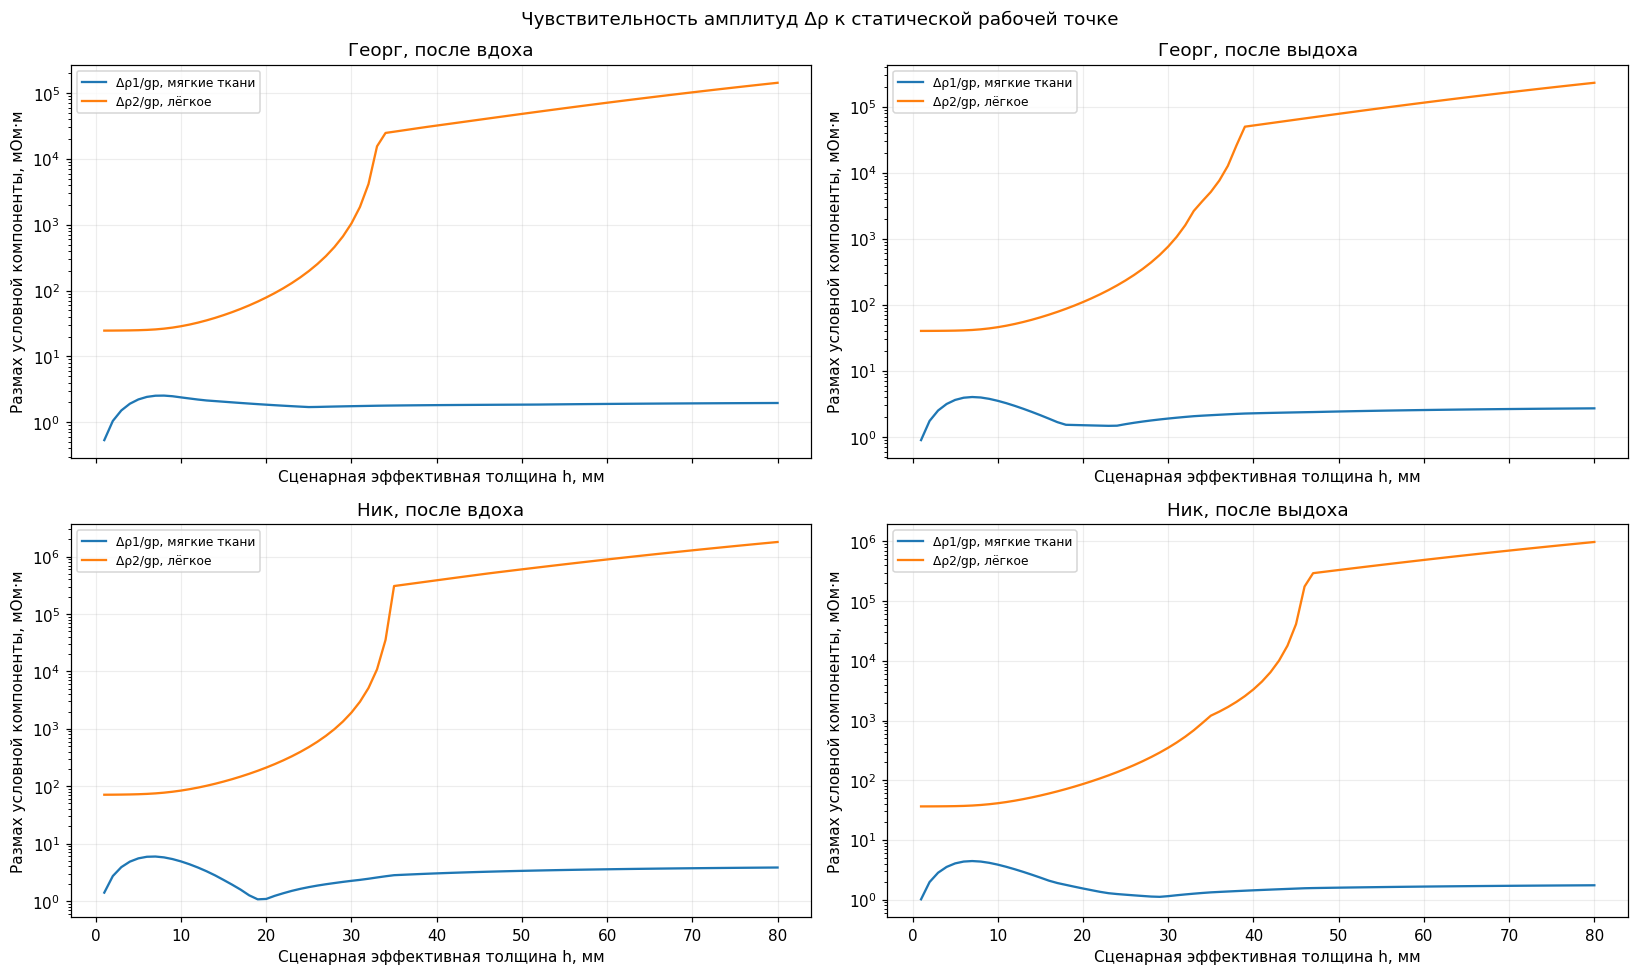

In [6]:
# Зависимость амплитуд условных компонент от сценария h
fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharex=True)
for row_index, subject_id in enumerate(sorted(subject_results)):
    subject = subject_results[subject_id]
    for column_index, (mode, mode_label) in enumerate(MODE_LABELS.items()):
        axis = axes[row_index, column_index]
        scenarios = subject["modes"][mode]["scenarios"]
        h_mm = np.asarray([1000.0 * item["h_m"] for item in scenarios])
        ptp = 1000.0 * np.asarray([
            item["component_ptp_ohm_m_per_unit_gain"] for item in scenarios
        ])
        axis.semilogy(h_mm, ptp[:, 0], label="Δρ1/gp, мягкие ткани")
        axis.semilogy(h_mm, ptp[:, 1], label="Δρ2/gp, лёгкое")
        axis.set_title(f"{subject['report_label']}, {mode_label}")
        axis.set_xlabel("Сценарная эффективная толщина h, мм")
        axis.set_ylabel("Размах условной компоненты, мОм·м")
        axis.legend(fontsize=8)
fig.suptitle("Чувствительность амплитуд Δρ к статической рабочей точке")
fig.tight_layout()
plt.show()


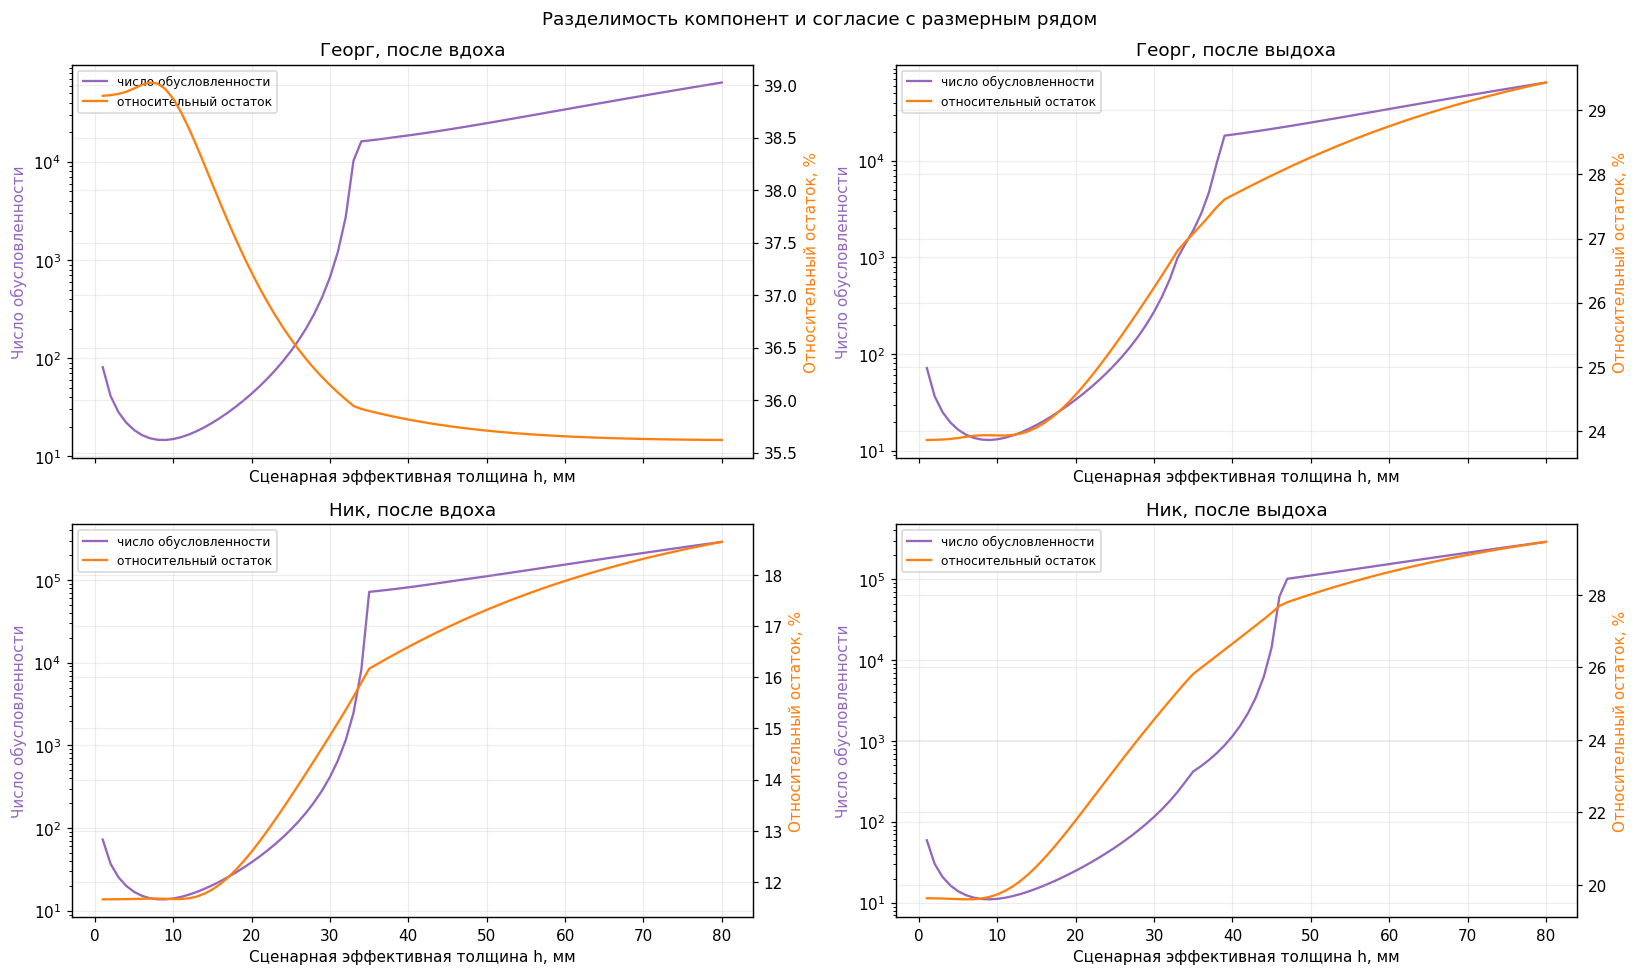

In [7]:
# Обусловленность оператора и остаток двуслойного представления
fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharex=True)
for row_index, subject_id in enumerate(sorted(subject_results)):
    subject = subject_results[subject_id]
    for column_index, (mode, mode_label) in enumerate(MODE_LABELS.items()):
        axis = axes[row_index, column_index]
        scenarios = subject["modes"][mode]["scenarios"]
        h_mm = np.asarray([1000.0 * item["h_m"] for item in scenarios])
        condition = np.asarray([item["operator_condition"] for item in scenarios])
        residual = 100.0 * np.asarray([
            item["relative_residual_norm"] for item in scenarios
        ])
        axis.semilogy(h_mm, condition, color="tab:purple", label="число обусловленности")
        residual_axis = axis.twinx()
        residual_axis.plot(h_mm, residual, color="tab:orange", label="относительный остаток")
        axis.set_title(f"{subject['report_label']}, {mode_label}")
        axis.set_xlabel("Сценарная эффективная толщина h, мм")
        axis.set_ylabel("Число обусловленности", color="tab:purple")
        residual_axis.set_ylabel("Относительный остаток, %", color="tab:orange")
        handles_1, labels_1 = axis.get_legend_handles_labels()
        handles_2, labels_2 = residual_axis.get_legend_handles_labels()
        axis.legend(handles_1 + handles_2, labels_1 + labels_2, fontsize=8)
fig.suptitle("Разделимость компонент и согласие с размерным рядом")
fig.tight_layout()
plt.show()


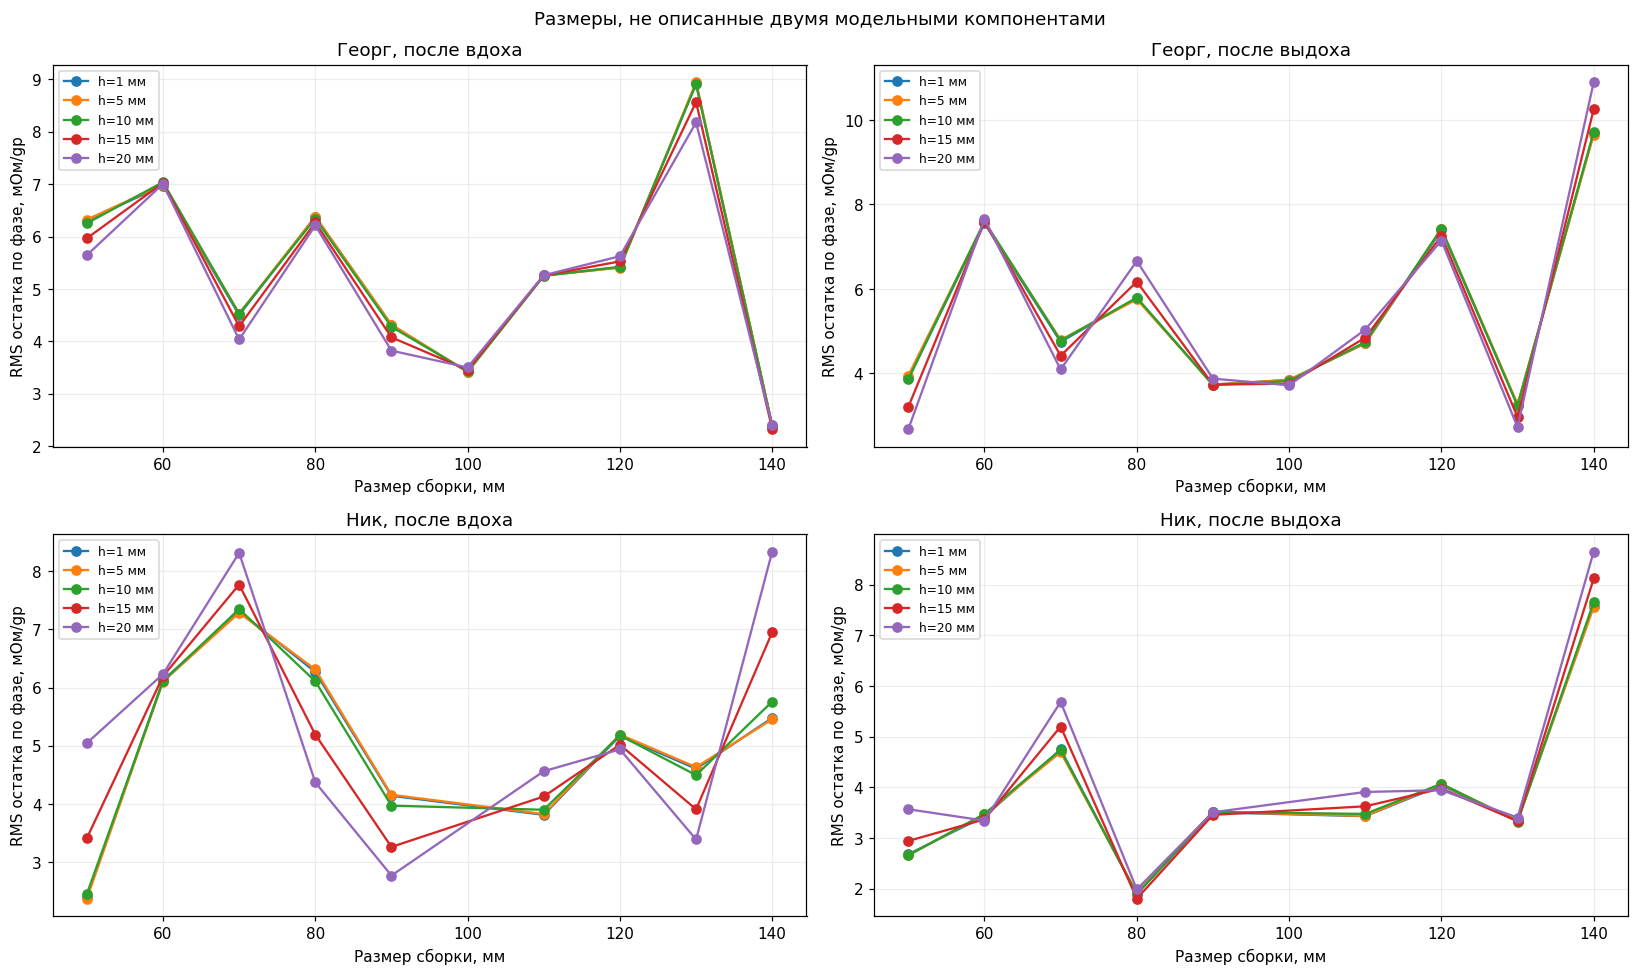

In [8]:
# Остаток для каждого размера: это расхождение модели с данными, а не оценка шума.
fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharex=False)
for row_index, subject_id in enumerate(sorted(subject_results)):
    subject = subject_results[subject_id]
    for column_index, (mode, mode_label) in enumerate(MODE_LABELS.items()):
        axis = axes[row_index, column_index]
        mode_result = subject["modes"][mode]
        sizes_mm = np.asarray(mode_result["sizes_mm"])
        by_h = {
            int(round(1000.0 * item["h_m"])): item
            for item in mode_result["scenarios"]
        }
        for h_mm in WAVEFORM_H_MM:
            residual_mohm = (
                1000.0
                * np.asarray(by_h[h_mm]["residual_rms_by_size_ohm_per_unit_gain"])
            )
            axis.plot(sizes_mm, residual_mohm, "o-", label=f"h={h_mm} мм")
        axis.set_title(f"{subject['report_label']}, {mode_label}")
        axis.set_xlabel("Размер сборки, мм")
        axis.set_ylabel("RMS остатка по фазе, мОм/gp")
        axis.legend(fontsize=8)
fig.suptitle("Размеры, не описанные двумя модельными компонентами")
fig.tight_layout()
plt.show()


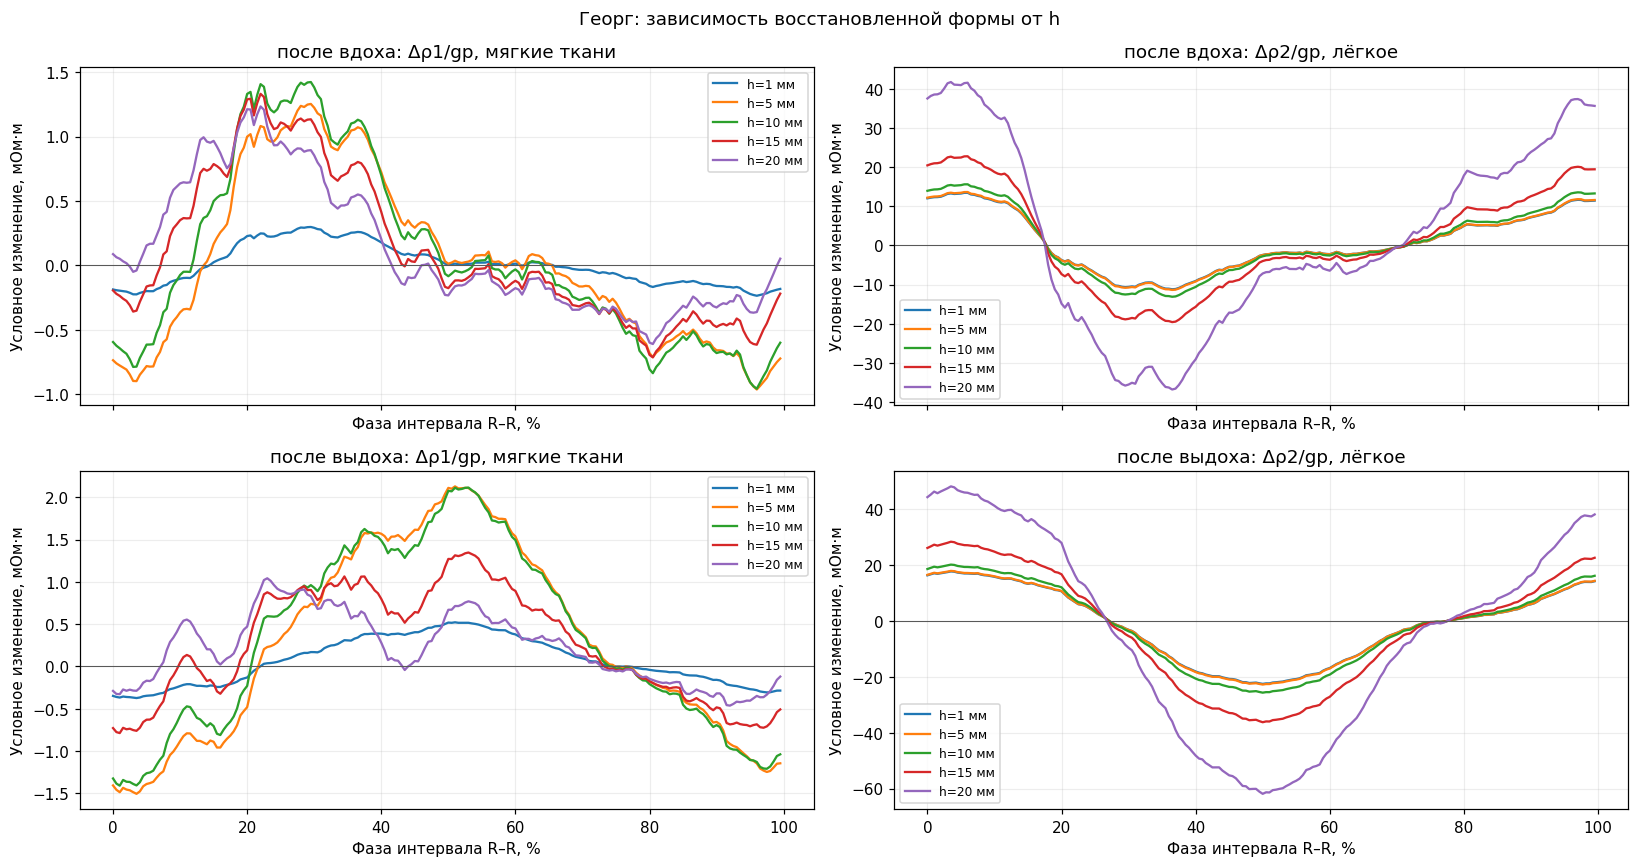

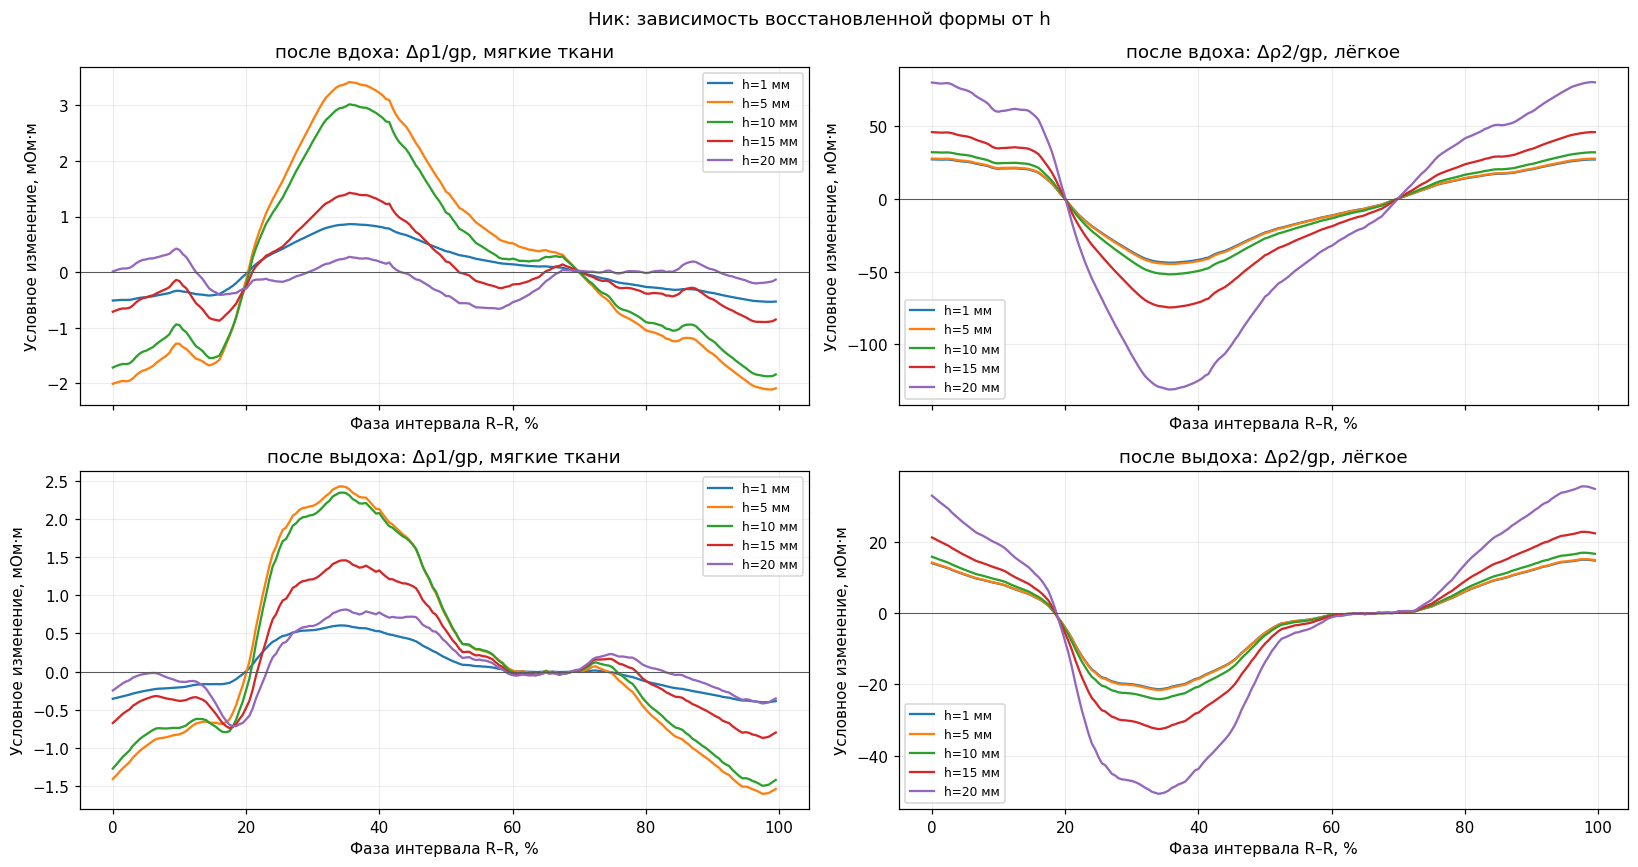

In [9]:
# Формы компонент в основном расчётном диапазоне h=1–20 мм
for subject_id in sorted(subject_results):
    subject = subject_results[subject_id]
    fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=True)
    for row_index, (mode, mode_label) in enumerate(MODE_LABELS.items()):
        mode_result = subject["modes"][mode]
        phase_percent = 100.0 * np.asarray(mode_result["phase_rr"])
        by_h = {
            int(round(1000.0 * item["h_m"])): item
            for item in mode_result["scenarios"]
        }
        for component_index, component_label in enumerate((
            "Δρ1/gp, мягкие ткани",
            "Δρ2/gp, лёгкое",
        )):
            axis = axes[row_index, component_index]
            for h_mm in WAVEFORM_H_MM:
                key = (
                    "delta_rho1_ohm_m_per_unit_gain"
                    if component_index == 0
                    else "delta_rho2_ohm_m_per_unit_gain"
                )
                waveform_mohm_m = 1000.0 * np.asarray(by_h[h_mm][key])
                axis.plot(phase_percent, waveform_mohm_m, label=f"h={h_mm} мм")
            axis.axhline(0.0, color="0.35", linewidth=0.7)
            axis.set_title(f"{mode_label}: {component_label}")
            axis.set_xlabel("Фаза интервала R–R, %")
            axis.set_ylabel("Условное изменение, мОм·м")
            axis.legend(fontsize=8)
    fig.suptitle(
        f"{subject['report_label']}: зависимость восстановленной формы от h"
    )
    fig.tight_layout()
    plt.show()


In [10]:
# Сводка чувствительности к h, отдельной записи и спорным циклам
sensitivity_rows = []
robustness_rows = []
for subject_id in sorted(subject_results):
    subject = subject_results[subject_id]
    for mode, mode_label in MODE_LABELS.items():
        scenarios = subject["modes"][mode]["scenarios"]
        core = [
            item for item in scenarios
            if 1000.0 * item["h_m"] <= CORE_H_MAX_MM + 1.0e-9
        ]
        unbounded = [
            item for item in scenarios if not item["static_parameter_bound_hit"]
        ]
        bounded_h = [
            int(round(1000.0 * item["h_m"]))
            for item in scenarios if item["static_parameter_bound_hit"]
        ]
        condition_core = np.asarray([item["operator_condition"] for item in core])
        residual_core = 100.0 * np.asarray([
            item["relative_residual_norm"] for item in core
        ])
        loo_core = 100.0 * np.asarray([
            change
            for item in core
            for row in item["leave_one_size_out"]
            for change in row["component_curve_change_fraction"]
        ])
        flag_core = 100.0 * np.asarray([
            change
            for item in core
            for change in item["candidate_flag_component_curve_change_fraction"]
        ])
        robustness_rows.append({
            "Доброволец": subject["report_label"],
            "Состояние": mode_label,
            "Число обусловленности при h=1–20 мм": (
                f"{condition_core.min():.1f}–{condition_core.max():.1f}"
            ),
            "Относительный остаток при h=1–20 мм, %": (
                f"{residual_core.min():.1f}–{residual_core.max():.1f}"
            ),
            "Макс. изменение при исключении размера, h=1–20 мм, %": float(
                np.nanmax(loo_core)
            ),
            "Макс. изменение без спорных циклов, h=1–20 мм, %": float(
                np.nanmax(flag_core)
            ),
            "Первое h с параметром на границе, мм": (
                min(bounded_h) if bounded_h else "нет"
            ),
        })

        ptp_all = np.asarray([
            item["component_ptp_ohm_m_per_unit_gain"] for item in scenarios
        ])
        ptp_core = np.asarray([
            item["component_ptp_ohm_m_per_unit_gain"] for item in core
        ])
        ptp_unbounded = np.asarray([
            item["component_ptp_ohm_m_per_unit_gain"] for item in unbounded
        ])
        for component_index, component_label in enumerate(("Δρ1", "Δρ2")):
            def positive_ratio(values):
                positive = values[:, component_index][values[:, component_index] > 0]
                return (
                    float(positive.max() / positive.min())
                    if len(positive) else np.nan
                )

            loo_max = float(np.nanmax([
                item["component_curve_change_fraction"][component_index]
                for scenario in core
                for item in scenario["leave_one_size_out"]
            ]))
            flag_max = float(np.nanmax([
                scenario["candidate_flag_component_curve_change_fraction"][component_index]
                for scenario in core
            ]))
            sensitivity_rows.append({
                "Доброволец": subject["report_label"],
                "Состояние": mode_label,
                "Компонента": component_label,
                "Макс./мин. размах при h=1–20 мм": positive_ratio(ptp_core),
                "Макс./мин. размах до границы параметров": positive_ratio(ptp_unbounded),
                "Макс./мин. размах по всей сетке": positive_ratio(ptp_all),
                "Макс. изменение при исключении размера, %": 100.0 * loo_max,
                "Макс. изменение без спорных циклов, %": 100.0 * flag_max,
            })

robustness_df = pd.DataFrame(robustness_rows)
sensitivity_df = pd.DataFrame(sensitivity_rows)
display(robustness_df.round(1))
display(sensitivity_df.round(1))

all_scenarios = [
    scenario
    for subject in subject_results.values()
    for mode in subject["modes"].values()
    for scenario in mode["scenarios"]
]
core_scenarios = [
    item for item in all_scenarios
    if 1000.0 * item["h_m"] <= CORE_H_MAX_MM + 1.0e-9
]
unbounded_scenarios = [
    item for item in all_scenarios if not item["static_parameter_bound_hit"]
]
all_full_rank = all(item["operator_rank"] == 2 for item in all_scenarios)
condition_core = np.asarray([item["operator_condition"] for item in core_scenarios])
condition_unbounded = np.asarray([
    item["operator_condition"] for item in unbounded_scenarios
])
cosine_core = np.asarray([
    item["operator_absolute_column_cosine"] for item in core_scenarios
])
residual_core = 100.0 * np.asarray([
    item["relative_residual_norm"] for item in core_scenarios
])
loo_core = 100.0 * np.asarray([
    change
    for item in core_scenarios
    for row in item["leave_one_size_out"]
    for change in row["component_curve_change_fraction"]
])
flag_core = 100.0 * np.asarray([
    change
    for item in core_scenarios
    for change in item["candidate_flag_component_curve_change_fraction"]
])
bounded_count = len(all_scenarios) - len(unbounded_scenarios)

rank_text = (
    "Во всех сценариях оператор имеет полный ранг 2."
    if all_full_rank
    else "В части сценариев оператор не имеет полного ранга 2."
)
display(Markdown(fr"""## Итог математической проверки

{rank_text} Следовательно, при фиксированной рабочей точке решение по всем
размерам формально является единственной точкой метода наименьших квадратов,
а не множеством пересечений. В основном расчётном диапазоне $h=1$–20 мм число
обусловленности изменяется от {condition_core.min():.2f} до
{condition_core.max():.2f}, а модуль косинуса между столбцами — от
{cosine_core.min():.4f} до {cosine_core.max():.4f}. Полный ранг поэтому не
следует отождествлять с надёжным разделением тканей.

В диапазоне $h=1$–20 мм относительная норма остатка составляет
{residual_core.min():.1f}–{residual_core.max():.1f} %. Этот остаток показывает
долю размерно-фазовой структуры, которую два модельных вклада не
воспроизводят. По данным одного расчёта нельзя разделить анатомическое
несоответствие, межзаписную изменчивость и приборные эффекты.

Максимальное изменение формы компоненты при исключении одной размерной записи
в том же диапазоне равно {np.nanmax(loo_core):.1f} %, а при удалении циклов с
кандидатной меткой ЭКГ — {np.nanmax(flag_core):.1f} %. Эти величины являются
детерминированными проверками чувствительности на имеющихся данных, а не
оценками случайного шума или доверительными границами.

За пределами 20 мм обусловленность продолжает ухудшаться и ещё до достижения
параметрами численных границ возрастает до {condition_unbounded.max():.1f}.
В {bounded_count} сценариях статическая подгонка достигла границы заданного
диапазона. Резкий рост условной $\Delta\rho_2$ в этой области является
признаком срыва выбранной параметризации, а не физическим увеличением
пульсового изменения удельного сопротивления лёгкого.

Выбор двух наиболее устойчивых размеров не превращает результат в
валидированное физическое измерение. Пара даёт точное алгебраическое решение
двух уравнений, но скрывает невязку остальных размеров. Для разработки
методики разумнее сохранять полный размерный ряд как проверку модели, а пару
рассматривать позднее после фиксации критерия точности и проверки
воспроизводимости.

Однозначные абсолютные значения $\Delta\rho_1$ и $\Delta\rho_2$ на этом
этапе не определены. Их масштаб пропорционален неизвестному $g_p$, знак определяется
неизвестным $s$, а форма и соотношение компонент дополнительно зависят от
выбранного сценария $h$ и статической рабочей точки. Числа в таблицах и на графиках
следует читать как условные коэффициенты двуслойной модели на единицу
пульсовой калибровки.
"""))


,Доброволец,Состояние,Число обусловленности при h=1–20 мм,"Относительный остаток при h=1–20 мм, %","Макс. изменение при исключении размера, h=1–20 мм, %","Макс. изменение без спорных циклов, h=1–20 мм, %","Первое h с параметром на границе, мм"
0,Георг,после вдоха,14.6–80.9,37.2–39.0,85.7,18.0,34
1,Георг,после выдоха,12.9–71.9,23.9–24.6,56.6,11.3,34
2,Ник,после вдоха,13.8–72.6,11.7–12.6,135.2,4.3,35
3,Ник,после выдоха,11.1–59.5,19.6–21.8,68.2,8.7,35


,Доброволец,Состояние,Компонента,Макс./мин. размах при h=1–20 мм,Макс./мин. размах до границы параметров,Макс./мин. размах по всей сетке,"Макс. изменение при исключении размера, %","Макс. изменение без спорных циклов, %"
0,Георг,после вдоха,Δρ1,4.7,4.7,4.7,85.7,18.0
1,Георг,после вдоха,Δρ2,3.2,630.6,5823.4,29.7,8.0
2,Георг,после выдоха,Δρ1,4.5,4.5,4.5,56.6,11.3
3,Георг,после выдоха,Δρ2,2.7,65.4,5688.1,16.9,3.7
4,Ник,после вдоха,Δρ1,5.6,5.6,5.6,135.2,4.3
5,Ник,после вдоха,Δρ2,3.0,499.6,25361.5,8.3,0.2
6,Ник,после выдоха,Δρ1,4.4,4.4,4.4,68.2,8.7
7,Ник,после выдоха,Δρ2,2.4,24.9,27007.2,15.5,2.2


## Итог математической проверки

Во всех сценариях оператор имеет полный ранг 2. Следовательно, при фиксированной рабочей точке решение по всем
размерам формально является единственной точкой метода наименьших квадратов,
а не множеством пересечений. В основном расчётном диапазоне $h=1$–20 мм число
обусловленности изменяется от 11.06 до
80.87, а модуль косинуса между столбцами — от
0.8500 до 0.9442. Полный ранг поэтому не
следует отождествлять с надёжным разделением тканей.

В диапазоне $h=1$–20 мм относительная норма остатка составляет
11.7–39.0 %. Этот остаток показывает
долю размерно-фазовой структуры, которую два модельных вклада не
воспроизводят. По данным одного расчёта нельзя разделить анатомическое
несоответствие, межзаписную изменчивость и приборные эффекты.

Максимальное изменение формы компоненты при исключении одной размерной записи
в том же диапазоне равно 135.2 %, а при удалении циклов с
кандидатной меткой ЭКГ — 18.0 %. Эти величины являются
детерминированными проверками чувствительности на имеющихся данных, а не
оценками случайного шума или доверительными границами.

За пределами 20 мм обусловленность продолжает ухудшаться и ещё до достижения
параметрами численных границ возрастает до 10310.2.
В 186 сценариях статическая подгонка достигла границы заданного
диапазона. Резкий рост условной $\Delta\rho_2$ в этой области является
признаком срыва выбранной параметризации, а не физическим увеличением
пульсового изменения удельного сопротивления лёгкого.

Выбор двух наиболее устойчивых размеров не превращает результат в
валидированное физическое измерение. Пара даёт точное алгебраическое решение
двух уравнений, но скрывает невязку остальных размеров. Для разработки
методики разумнее сохранять полный размерный ряд как проверку модели, а пару
рассматривать позднее после фиксации критерия точности и проверки
воспроизводимости.

Однозначные абсолютные значения $\Delta\rho_1$ и $\Delta\rho_2$ на этом
этапе не определены. Их масштаб пропорционален неизвестному $g_p$, знак определяется
неизвестным $s$, а форма и соотношение компонент дополнительно зависят от
выбранного сценария $h$ и статической рабочей точки. Числа в таблицах и на графиках
следует читать как условные коэффициенты двуслойной модели на единицу
пульсовой калибровки.


## Отдельный сценарий с историческим КТ-

Сценарный перебор $h=1\ldots80$ мм отвечает на вопрос о чувствительности
обратной задачи к толщине. Ниже отдельно воспроизводится прежний расчёт в
конкретных точках: 15 мм для Ника и 40 мм для Георга. Статические
$(\rho_1,\rho_2)$ берутся из нового артефакта `33.01`, полученного при этих
фиксированных значениях $h$.

Это не новая валидация КТ. Значения $h$ сохранены в исторических файлах проекта
как перенесённые из ручной сегментации Inobitec, но правило измерения толщины,
место бокового монтажа и повторное получение чисел из масок пока не
воспроизведены. Поэтому результат имеет статус исторического вычислительного
воспроизведения.

К пульсовому сигналу сохраняются те же ограничения: `RHEO2` номинально
переводится из мОм в Ом, но его коэффициент усиления, физический знак и
частотная характеристика неизвестны. Следовательно, показаны условные
$\Delta\rho_1/g_p$ и $\Delta\rho_2/g_p$, а не калиброванные физические
изменения удельного сопротивления.

В старом пульсовом расчёте при наличии `params/ct.json` дополнительно
подставлялась КТ/HU-оценка $\rho_2$ вместо статически восстановленной
$\rho_2$. Поэтому перенос разделён на две проверки: основной новый вариант
использует всю статическую рабочую точку `33.01`, а отдельный блок ниже
воспроизводит прежнюю подстановку $h_{КТ}$ и $\rho_{2,КТ}$. Эти варианты нельзя
смешивать или считать взаимозаменяемыми.

,Доброволец,Состояние,"h, мм","ρ1, Ом·м","ρ2, Ом·м",Число обусловленности,"Относительный остаток, %","Размах Δρ1/gp, мОм·м","Размах Δρ2/gp, мОм·м",Лучшая пара,Статический параметр на границе
0,Георг,после вдоха,40.0,13.2086,200.0000,867.84,35.9,1.8083,1620.4654,60–140,да
1,Георг,после выдоха,40.0,13.2086,200.0000,867.84,27.3,2.2091,2632.5764,60–140,да
2,Ник,после вдоха,15.0,4.7486,17.1234,20.40,11.9,2.3223,120.3456,50–140,нет
3,Ник,после выдоха,15.0,4.7486,14.2732,15.01,20.5,2.3267,55.2834,60–140,нет


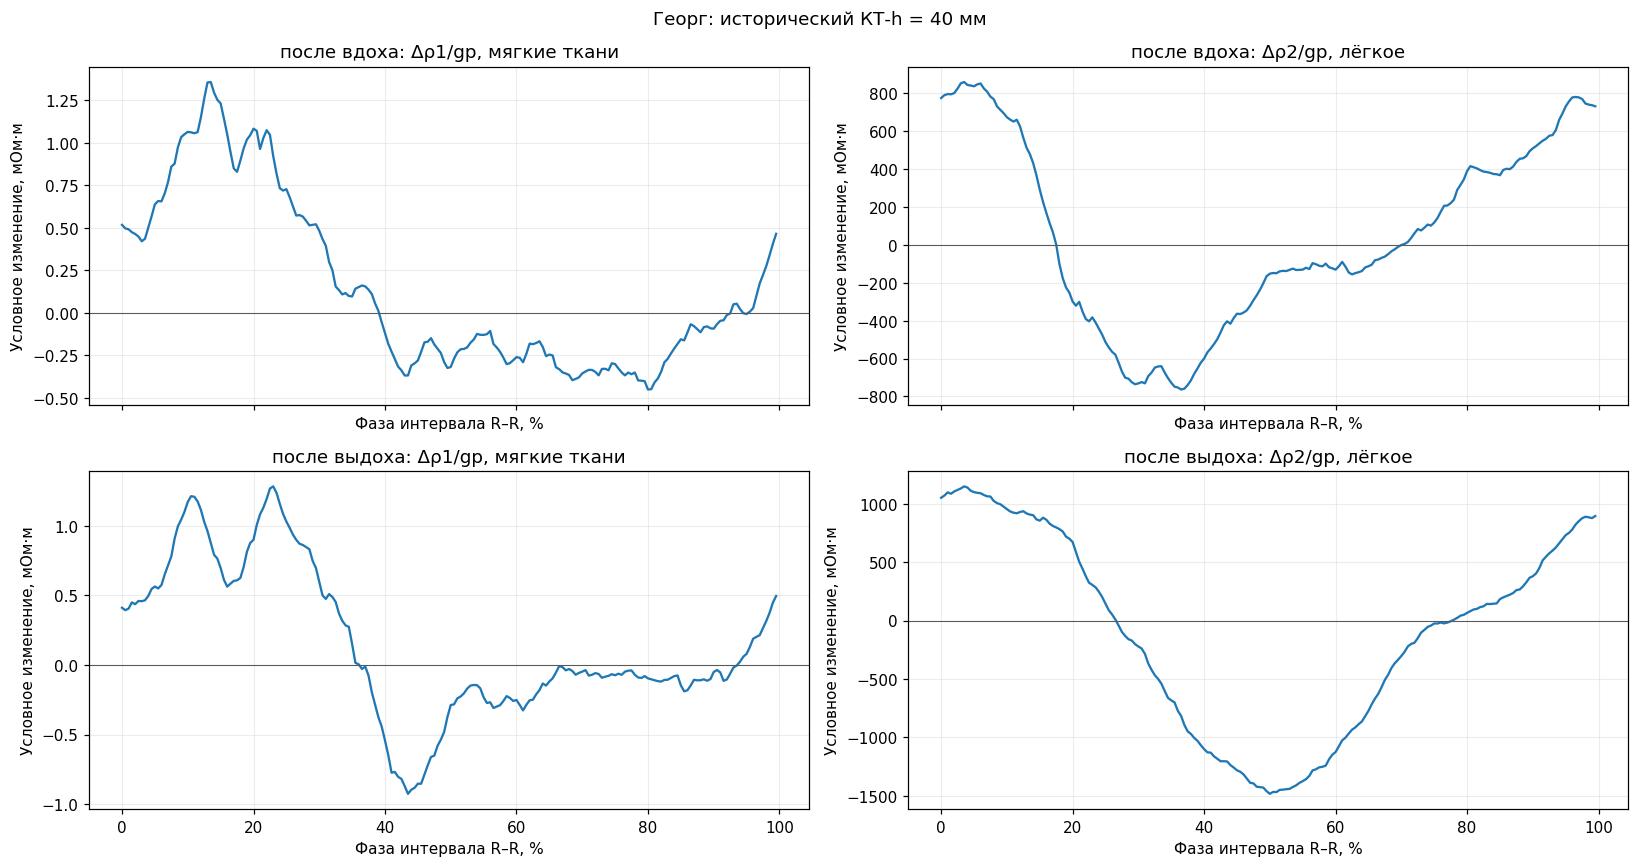

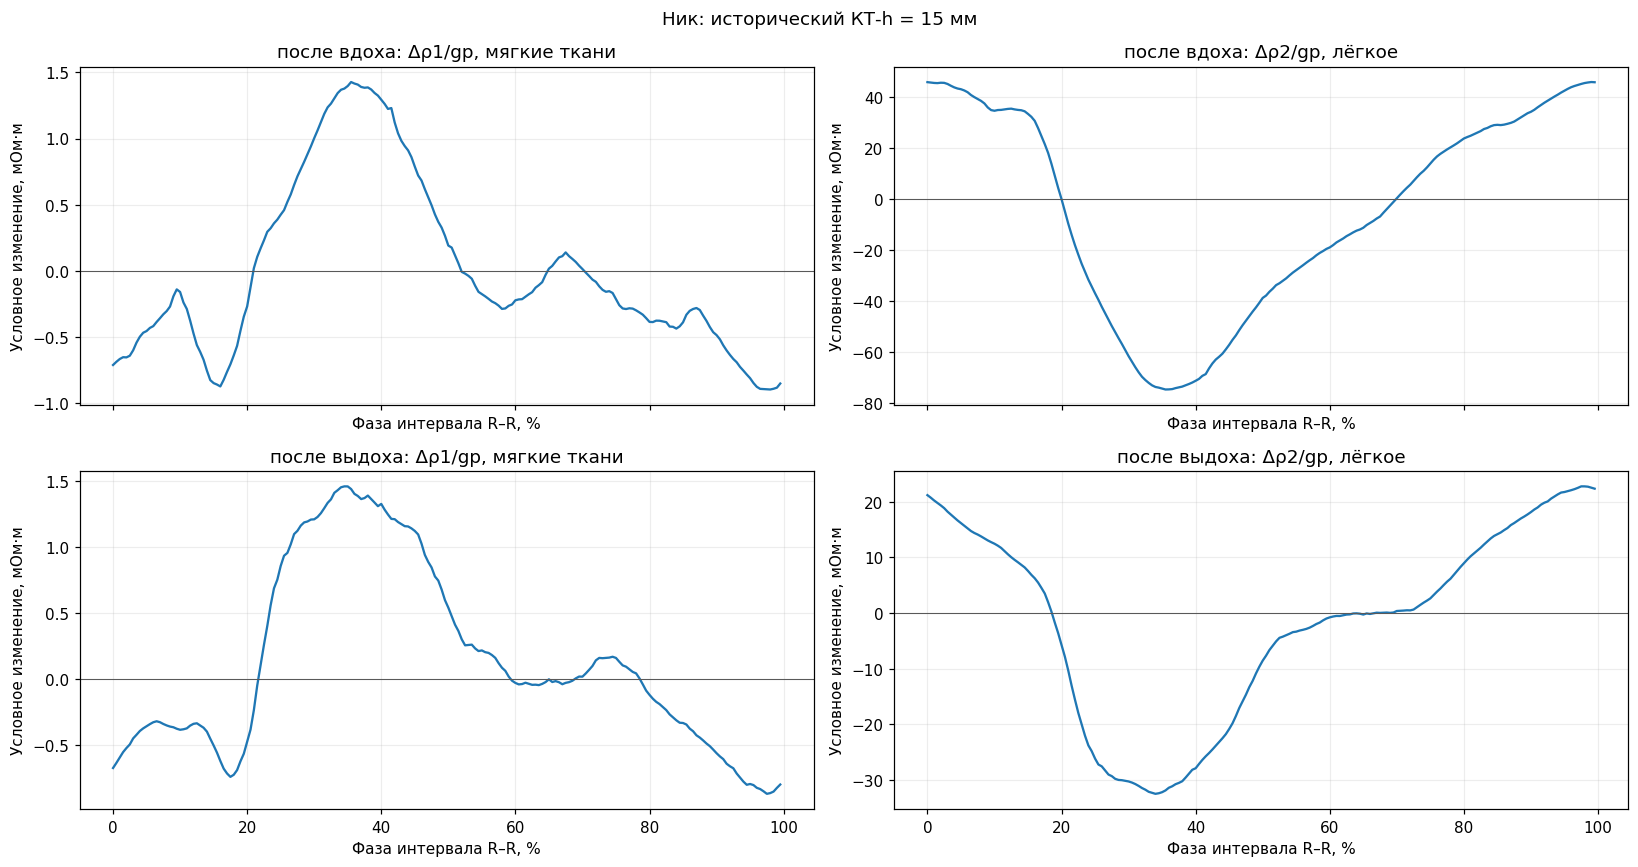

**Вывод по КТ-сценарию.** Исторические значения $h$ теперь проходят через полную новую цепочку `33.01 → 33.04`. Полученные числа остаются условными: для добровольца, у которого статическая $\rho_2$ достигает границы, динамическое разделение особенно чувствительно к выбранной рабочей точке. Само воспроизведение не подтверждает ни анатомическую корректность $h$, ни физическую шкалу `RHEO2`.

Внешний результат КТ-сценария: 33.04_delta_rho_historical_ct.provisional.json


In [11]:
ct_static_path = (
    exploratory_dir / "33.01_historical_ct_reproduction.provisional.json"
)
ct_static_artifact = json.loads(ct_static_path.read_text(encoding="utf-8"))
if ct_static_artifact.get("status") != "historical_ct_h_reproduction_not_revalidated":
    raise RuntimeError("33.01 не содержит ожидаемого исторического КТ-сценария")
if ct_static_artifact.get("strict_pipeline_authorized") is not False:
    raise RuntimeError("Исторический КТ-сценарий ошибочно помечен как строгий")

ct_subject_results = {}
ct_summary_rows = []
for subject_id, static_subject in sorted(ct_static_artifact["subjects"].items()):
    sizes_mm = np.asarray(static_subject["sizes_mm"], dtype=int)
    estimate = static_subject["estimate"]
    static_row = {
        "h_m": float(static_subject["h_m"]),
        "rho1_ohm_m": float(estimate["rho1_ohm_m"]),
        "rho2_inhale_ohm_m": float(estimate["rho2_inhale_ohm_m"]),
        "rho2_exhale_ohm_m": float(estimate["rho2_exhale_ohm_m"]),
        "parameter_bound_hit": bool(estimate["parameter_bound_hit"]),
    }
    modes = {}
    for mode, mode_label in MODE_LABELS.items():
        primary = []
        no_flag = []
        phase_grid = None
        for size_mm in sizes_mm:
            ensemble = ensemble_index[(subject_id, int(size_mm), mode)]
            current_phase = np.asarray(ensemble["phase_rr"], dtype=float)
            if phase_grid is None:
                phase_grid = current_phase
            elif not np.array_equal(phase_grid, current_phase):
                raise RuntimeError("Фазовые сетки 33.03 не совпадают")
            primary.append(
                np.asarray(ensemble["primary"]["median_mohm"], dtype=float)
                * NOMINAL_MOHM_TO_OHM
            )
            no_flag.append(
                np.asarray(
                    ensemble["sensitivity_without_candidate_ecg_flags"]["median_mohm"],
                    dtype=float,
                ) * NOMINAL_MOHM_TO_OHM
            )
        scenario = analyze_scenario(
            sizes_mm,
            np.asarray(primary),
            np.asarray(no_flag),
            static_row,
            MODE_TO_STATE[mode],
        )
        modes[mode] = {
            "mode_label": mode_label,
            "phase_rr": phase_grid,
            "sizes_mm": sizes_mm,
            "scenario": scenario,
        }
        ct_summary_rows.append({
            "Доброволец": static_subject["report_label"],
            "Состояние": mode_label,
            "h, мм": 1000.0 * static_row["h_m"],
            "ρ1, Ом·м": static_row["rho1_ohm_m"],
            "ρ2, Ом·м": static_row[f"rho2_{MODE_TO_STATE[mode]}_ohm_m"],
            "Число обусловленности": scenario["operator_condition"],
            "Относительный остаток, %": 100.0 * scenario["relative_residual_norm"],
            "Размах Δρ1/gp, мОм·м": 1000.0 * scenario["component_ptp_ohm_m_per_unit_gain"][0],
            "Размах Δρ2/gp, мОм·м": 1000.0 * scenario["component_ptp_ohm_m_per_unit_gain"][1],
            "Лучшая пара": "–".join(map(str, scenario["best_conditioned_pair"]["sizes_mm"])),
            "Статический параметр на границе": "да" if scenario["static_parameter_bound_hit"] else "нет",
        })
    ct_subject_results[subject_id] = {
        "report_label": static_subject["report_label"],
        "h_source": static_subject["h_source"],
        "h_validation_status": static_subject["h_validation_status"],
        "static_estimate": estimate,
        "modes": modes,
    }

ct_result_artifact = {
    "schema_version": 1,
    "analysis": "33.04_dynamic_inverse_at_historical_ct_h",
    "algorithm_version": "series33-delta-rho-historical-ct-reproduction-v1",
    "status": "historical_ct_h_reproduction_not_revalidated",
    "strict_pipeline_authorized": False,
    "experiment": 2,
    "upstream": {
        "pulse_ensembles": pulse_path.name,
        "static_historical_ct": ct_static_path.name,
    },
    "calibration_scenario": {
        "nominal_mohm_to_ohm": NOMINAL_MOHM_TO_OHM,
        "pulse_gain": "unknown_results_are_per_unit_gain",
        "physical_sign": "unknown_opposite_sign_negates_both_components",
    },
    "assumptions": [
        "historical_CT_h_is_fixed_and_equal_for_both_breathing_states",
        "two_layer_flat_halfspace_is_applicable",
        "linearization_is_adequate_for_the_pulse_excursion",
        "sequential_size_recordings_share_one_latent_phase_normalized_response",
        "size_specific_channel_gain_is_absent",
    ],
    "limitations": [
        "h_was_not_recomputed_from_CT_masks_or_STL",
        "absolute_delta_rho_is_not_identified_without_pulse_calibration",
        "physical_sign_is_unknown",
        "static_BASE2_scale_is_not_calibrated",
        "no_probabilistic_error_model_or_confidence_intervals",
        "no_CT_FEM_validation_of_the_sensitivity_operator",
    ],
    "subjects": ct_subject_results,
}
ct_output_path = exploratory_dir / "33.04_delta_rho_historical_ct.provisional.json"
ct_temporary_path = ct_output_path.with_suffix(ct_output_path.suffix + ".tmp")
ct_temporary_path.write_text(
    json.dumps(json_ready(ct_result_artifact), ensure_ascii=False, indent=2) + "\n",
    encoding="utf-8",
)
ct_temporary_path.replace(ct_output_path)

ct_summary_df = pd.DataFrame(ct_summary_rows)
display(ct_summary_df.round({
    "h, мм": 0,
    "ρ1, Ом·м": 4,
    "ρ2, Ом·м": 4,
    "Число обусловленности": 2,
    "Относительный остаток, %": 1,
    "Размах Δρ1/gp, мОм·м": 4,
    "Размах Δρ2/gp, мОм·м": 4,
}))

for subject_id, subject in sorted(ct_subject_results.items()):
    fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=True)
    for row_index, (mode, mode_label) in enumerate(MODE_LABELS.items()):
        mode_result = subject["modes"][mode]
        phase_percent = 100.0 * np.asarray(mode_result["phase_rr"])
        scenario = mode_result["scenario"]
        for component_index, key in enumerate((
            "delta_rho1_ohm_m_per_unit_gain",
            "delta_rho2_ohm_m_per_unit_gain",
        )):
            axis = axes[row_index, component_index]
            axis.plot(phase_percent, 1000.0 * np.asarray(scenario[key]))
            axis.axhline(0.0, color="0.35", linewidth=0.7)
            axis.set_title(
                f"{mode_label}: "
                f"{'Δρ1/gp, мягкие ткани' if component_index == 0 else 'Δρ2/gp, лёгкое'}"
            )
            axis.set_xlabel("Фаза интервала R–R, %")
            axis.set_ylabel("Условное изменение, мОм·м")
    h_mm = 1000.0 * next(iter(subject["modes"].values()))["scenario"]["h_m"]
    fig.suptitle(f"{subject['report_label']}: исторический КТ-h = {h_mm:.0f} мм")
    fig.tight_layout()
    plt.show()

display(Markdown(
    "**Вывод по КТ-сценарию.** Исторические значения $h$ теперь проходят через "
    "полную новую цепочку `33.01 → 33.04`. Полученные числа остаются условными: "
    "для добровольца, у которого статическая $\\rho_2$ достигает границы, "
    "динамическое разделение особенно чувствительно к выбранной рабочей точке. "
    "Само воспроизведение не подтверждает ни анатомическую корректность $h$, "
    "ни физическую шкалу `RHEO2`."
))
print("Внешний результат КТ-сценария:", ct_output_path.name)


### Совместимость со старым пульсовым методом

Старый объединённый расчёт сводил каждый ансамбль к амплитуде `max − min`.
Для каждой пары размеров решалась система из двух линейных уравнений, а затем
точки пересечения усреднялись с весом $\sin^2\theta$, где $\theta$ — угол
между строками чувствительности. Ниже эта математика повторяется на проверенных
ансамблях `33.03` отдельно для двух задержек дыхания.

Это совместимость метода, а не побитовое повторение старого ноутбука: прежний
код объединял циклы без нынешнего разделения по дыхательным состояниям. Кроме
того, `max − min` уничтожает физический знак и фазу сигнала. Результат нужен,
чтобы увидеть, какие старые числа определялись именно выбором алгоритма и
КТ/HU-подстановкой $\rho_2$.

,Доброволец,Состояние,"h КТ, мм","ρ2 КТ/HU, Ом·м","Δρ1/gp, мОм·м","Δρ2/gp, мОм·м","Относительный остаток, %",Число пар
0,Георг,после вдоха,40.0,18.5913,1.1251,61.3208,22.7161,45
1,Георг,после выдоха,40.0,18.5913,2.7393,86.7990,18.0547,45
2,Ник,после вдоха,15.0,17.4067,-1.3265,117.7712,8.0971,36
3,Ник,после выдоха,15.0,17.4067,-1.0761,61.7737,15.6038,36


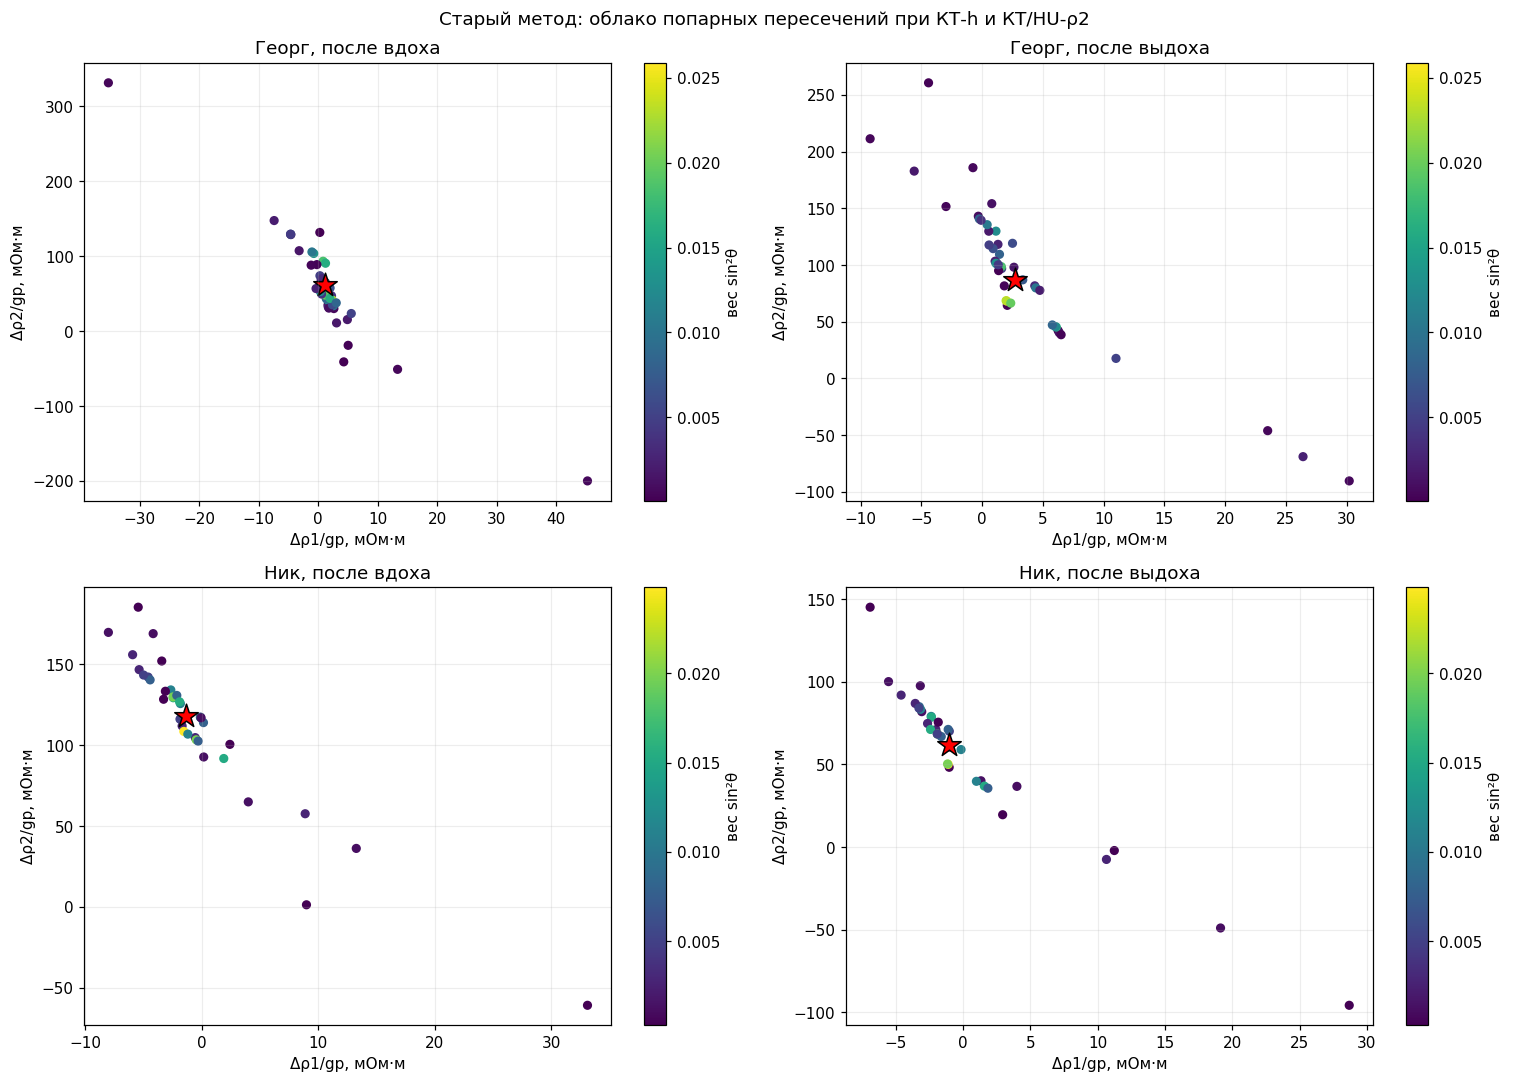

**Критический смысл сравнения.** Новый МНК-расчёт использует всю форму ансамбля и сохраняет остаток по всем размерам. Старый метод сначала заменяет форму одной положительной амплитудой, а затем усредняет решения разных пар. Расхождение результатов между этими блоками является чувствительностью к постановке обратной задачи, а не экспериментальным изменением ткани.

Внешний результат старого метода: 33.04_legacy_CT_pair_method.provisional.json


In [12]:
def legacy_weighted_pair_centroid(operator, amplitudes_ohm):
    operator = np.asarray(operator, dtype=float)
    amplitudes = np.asarray(amplitudes_ohm, dtype=float)
    points = []
    weights = []
    pairs = []
    for first, second in combinations(range(len(amplitudes)), 2):
        matrix = operator[[first, second], :]
        if np.linalg.matrix_rank(matrix) < 2:
            continue
        point = np.linalg.solve(matrix, amplitudes[[first, second]])
        first_row, second_row = matrix
        denominator = np.linalg.norm(first_row) * np.linalg.norm(second_row)
        cosine = np.dot(first_row, second_row) / denominator
        weight = float(max(0.0, 1.0 - np.clip(cosine, -1.0, 1.0) ** 2))
        points.append(point)
        weights.append(weight)
        pairs.append([int(first), int(second)])
    points = np.asarray(points, dtype=float)
    weights = np.asarray(weights, dtype=float)
    if len(points) == 0 or not np.any(weights > 0):
        raise RuntimeError("Нет устойчивых попарных пересечений")
    centroid = np.average(points, axis=0, weights=weights)
    predicted = operator @ centroid
    residual = amplitudes - predicted
    return {
        "centroid_ohm_m_per_unit_gain": centroid,
        "pair_points_ohm_m_per_unit_gain": points,
        "weights_sin2": weights,
        "pair_indices": pairs,
        "predicted_amplitude_ohm_per_unit_gain": predicted,
        "relative_residual_norm": float(
            np.linalg.norm(residual) / np.linalg.norm(amplitudes)
        ),
    }


legacy_method_subjects = {}
legacy_method_rows = []
for subject_id, static_subject in sorted(ct_static_artifact["subjects"].items()):
    sizes_mm = np.asarray(static_subject["sizes_mm"], dtype=int)
    estimate = static_subject["estimate"]
    static_row = {
        "h_m": float(static_subject["h_m"]),
        "rho1_ohm_m": float(estimate["rho1_ohm_m"]),
        "rho2_inhale_ohm_m": float(static_subject["legacy_ct_rho2_ohm_m"]),
        "rho2_exhale_ohm_m": float(static_subject["legacy_ct_rho2_ohm_m"]),
        "parameter_bound_hit": bool(estimate["parameter_bound_hit"]),
    }
    modes = {}
    for mode, mode_label in MODE_LABELS.items():
        waveforms = np.asarray([
            np.asarray(
                ensemble_index[(subject_id, int(size_mm), mode)]["primary"]["median_mohm"],
                dtype=float,
            ) * NOMINAL_MOHM_TO_OHM
            for size_mm in sizes_mm
        ])
        amplitudes = np.ptp(waveforms, axis=1)
        operator = two_layer_operator(sizes_mm, static_row, MODE_TO_STATE[mode])
        result = legacy_weighted_pair_centroid(operator, amplitudes)
        modes[mode] = {
            "mode_label": mode_label,
            "sizes_mm": sizes_mm,
            "amplitude_max_minus_min_ohm_per_unit_gain": amplitudes,
            "operator_ohm_per_ohm_m": operator,
            **result,
        }
        centroid = result["centroid_ohm_m_per_unit_gain"]
        legacy_method_rows.append({
            "Доброволец": static_subject["report_label"],
            "Состояние": mode_label,
            "h КТ, мм": 1000.0 * static_row["h_m"],
            "ρ2 КТ/HU, Ом·м": static_row["rho2_inhale_ohm_m"],
            "Δρ1/gp, мОм·м": 1000.0 * centroid[0],
            "Δρ2/gp, мОм·м": 1000.0 * centroid[1],
            "Относительный остаток, %": 100.0 * result["relative_residual_norm"],
            "Число пар": len(result["pair_points_ohm_m_per_unit_gain"]),
        })
    legacy_method_subjects[subject_id] = {
        "report_label": static_subject["report_label"],
        "h_m": static_row["h_m"],
        "rho1_static_ohm_m": static_row["rho1_ohm_m"],
        "rho2_legacy_ct_ohm_m": static_row["rho2_inhale_ohm_m"],
        "modes": modes,
    }

legacy_method_artifact = {
    "schema_version": 1,
    "analysis": "33.04_legacy_pair_intersection_with_h_and_rho2_CT",
    "algorithm_version": "series33-legacy-pair-centroid-compatibility-v1",
    "status": "legacy_method_compatibility_not_exact_raw_replay",
    "strict_pipeline_authorized": False,
    "experiment": 2,
    "upstream": {
        "pulse_ensembles": pulse_path.name,
        "static_historical_ct": ct_static_path.name,
    },
    "assumptions": [
        "h_is_legacy_CT_value",
        "rho2_is_legacy_CT_HU_conversion",
        "pulse_amplitude_is_max_minus_min_and_has_no_sign",
        "pair_intersections_are_combined_with_sin2_angle_weights",
        "RHEO2_scale_is_nominal_per_unit_unknown_gain",
    ],
    "limitations": [
        "not_an_exact_raw_replay_because_33_03_ensembles_are_split_by_breathing_state",
        "h_and_rho2_CT_provenance_are_not_revalidated",
        "max_minus_min_discards_sign_and_phase",
        "BASE2_and_RHEO2_are_not_calibrated",
        "pair_cloud_is_not_a_probabilistic_confidence_region",
    ],
    "subjects": legacy_method_subjects,
}
legacy_method_path = exploratory_dir / "33.04_legacy_CT_pair_method.provisional.json"
legacy_method_tmp = legacy_method_path.with_suffix(legacy_method_path.suffix + ".tmp")
legacy_method_tmp.write_text(
    json.dumps(json_ready(legacy_method_artifact), ensure_ascii=False, indent=2) + "\n",
    encoding="utf-8",
)
legacy_method_tmp.replace(legacy_method_path)

display(pd.DataFrame(legacy_method_rows).round(4))
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for row_index, (subject_id, subject) in enumerate(sorted(legacy_method_subjects.items())):
    for column_index, (mode, mode_label) in enumerate(MODE_LABELS.items()):
        axis = axes[row_index, column_index]
        result = subject["modes"][mode]
        points = np.asarray(result["pair_points_ohm_m_per_unit_gain"]) * 1000.0
        weights = np.asarray(result["weights_sin2"])
        centroid = np.asarray(result["centroid_ohm_m_per_unit_gain"]) * 1000.0
        scatter = axis.scatter(points[:, 0], points[:, 1], c=weights, cmap="viridis", s=25)
        axis.scatter(centroid[0], centroid[1], marker="*", s=260, color="red", edgecolor="black")
        axis.set_title(f"{subject['report_label']}, {mode_label}")
        axis.set_xlabel("Δρ1/gp, мОм·м")
        axis.set_ylabel("Δρ2/gp, мОм·м")
        fig.colorbar(scatter, ax=axis, label="вес sin²θ")
fig.suptitle("Старый метод: облако попарных пересечений при КТ-h и КТ/HU-ρ2")
fig.tight_layout()
plt.show()

display(Markdown(
    "**Критический смысл сравнения.** Новый МНК-расчёт использует всю форму "
    "ансамбля и сохраняет остаток по всем размерам. Старый метод сначала "
    "заменяет форму одной положительной амплитудой, а затем усредняет решения "
    "разных пар. Расхождение результатов между этими блоками является "
    "чувствительностью к постановке обратной задачи, а не экспериментальным "
    "изменением ткани."
))
print("Внешний результат старого метода:", legacy_method_path.name)


## Научная интерпретация и следующий шаг

Расчёт отвечает на ограниченный вопрос: допускает ли выбранная аналитическая
модель численное разложение наблюдаемого размерного ряда на два столбца
чувствительности. Даже положительный ответ не устанавливает анатомическое
происхождение компонент. Для тетраполярного передаточного импеданса знак
локальной чувствительности зависит от взаимной ориентации токового и
измерительного полей; сердечная синхронность также не локализует источник
сигнала. Это ограничение согласуется с работой E. Naydenova, S. Cavendish и
A. J. Wilson о моделировании чувствительности тетраполярных измерений
([DOI: 10.1016/j.medengphy.2016.07.005](https://doi.org/10.1016/j.medengphy.2016.07.005)).

Следующий обоснованный этап состоит из двух раздельных проверок. Сначала нужно
установить оператор канала `RHEO2`: номинальную единицу, коэффициент усиления,
физический знак, частотную характеристику и межканальное влияние. Затем
аналитические столбцы чувствительности следует сравнить с индивидуальными
КТ/FEM-моделями для реальных расположений электродов. До этих проверок
результат `33.04` нельзя переносить в коррекцию ТТРКГ или расчёт функций
сердца.

Фазовая ось R–R пригодна для сравнения формы, но не для оценки задержки в
миллисекундах. Временные характеристики должны рассчитываться в `33.05` по
исходному времени каждого кардиоцикла.
